In [164]:
# ! pip install faraway

### Step 0

In [165]:
# CodeGrade step0

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

# CodeGrade step0

# Load the Dataset from faraway
from faraway.datasets import pima

# Load the dataset
data = pima.load()

# Convert 'diabetes' column to int type to represent classes 0 and 1; remove the handful of 2s (unkown) in the data
data['diabetes'] = data['diabetes'].astype(int)
data = data[data['diabetes'] != 2]




### Step 1

*  [Data](https://rdrr.io/cran/faraway/man/pima.html)
*  [Faraway](https://pypi.org/project/faraway/)

In [166]:
# CodeGrade step1

# Shape

data.shape

(764, 9)

### Step 2

In [167]:
# CodeGrade step2

#  Define Features and Scale the Data
# Define features (X) and target (y)
X = data.drop('diabetes', axis=1)
y = data['diabetes']
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Return only the shapes (as required)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((611, 8), (153, 8), (611,), (153,))

### Step 3


In [168]:
# CodeGrade step3

# Build and Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm

array([[147,   1],
       [  5,   0]])

### Step 4

In [169]:
# CodeGrade step4

report = classification_report(y_test, y_pred, output_dict=True)

report['0']['precision']

0.9671052631578947

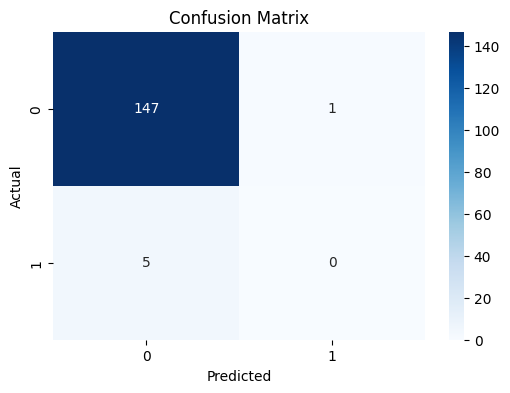

In [170]:
# Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

### Step 5

In [171]:
# CodeGrade step5

from sklearn.metrics import roc_auc_score, roc_curve

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Return required values
auc, sum(fpr), sum(tpr), sum(thresholds)

(0.6837837837837838,
 np.float64(4.168918918918919),
 np.float64(6.0),
 np.float64(inf))

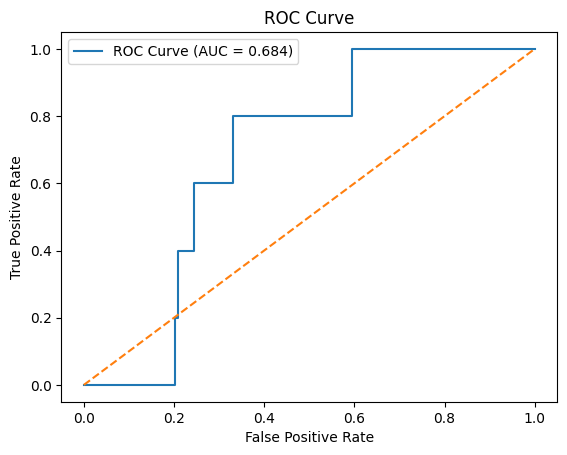

In [172]:
# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()